# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import math
import json
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


import torch.nn as nn
from torch.utils.data import  TensorDataset
from sklearn.model_selection import train_test_split
from skorch import NeuralNetClassifier
from skorch.helper import predefined_split
from skorch.callbacks import EpochScoring
from IPython.display import display
import torch
print(torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Random seed:", SEED)

SAVE_DIR = "learning_curves"
os.makedirs(SAVE_DIR, exist_ok=True)

from skorch.callbacks import EpochScoring, Checkpoint, EarlyStopping

import shutil
shutil.rmtree("checkpoints", ignore_errors=True)

NumPy: 2.5.1
Pandas: 3.0.5
2.13.0+cu132
Device: cuda
Random seed: 42


# Load Dataset

In [2]:
data = pd.read_csv(
    "gsar_a_2521295_sm1572.csv",
    sep=";",
    skiprows=1,
    encoding="utf-8-sig"
)

data = data.dropna(subset=["SMILES", "label"]).reset_index(drop=True)
data["label"] = data["label"].astype(int)

# ==== Dedup SMILES ====
n_before = data.shape[0]
label_nunique = data.groupby("SMILES")["label"].nunique()
conflicting_smiles = label_nunique[label_nunique > 1]
if len(conflicting_smiles) > 0:
    print(f"PERINGATAN: {len(conflicting_smiles)} SMILES punya label yang beda-beda (bukan cuma duplikat murni):")
    print(conflicting_smiles.index.tolist())

data = data.drop_duplicates(subset=["SMILES"], keep="first").reset_index(drop=True)
n_after = data.shape[0]
print(f"Deduplikat: {n_before} -> {n_after} baris ({n_before - n_after} duplikat dibuang)")

print(data.shape)
data[["compound ID", "SMILES", "label"]].head()

Deduplikat: 846 -> 846 baris (0 duplikat dibuang)
(846, 8)


,compound ID,SMILES,label
0,A001,FC1(F)CN(c2c(C(F)(F)F)cnc3[nH]c(C4=CCNC4)cc23)C1,1
1,A002,CC(C)[C@@H](NC(=O)c1cc(-c2cnn3cc(-c4ccc(OCCN5C...,1
2,A003,O=C(NCC(F)(F)F)c1cc(-c2cnc3[nH]c(C4=CCCNC4)cc3...,1
3,A004,CN1CC=C(c2cc3cc(-c4csc(C(=O)NCC(F)(F)F)c4)cnc3...,1
4,A005,O=C(NCC(F)(F)F)c1cc(-c2cnc3[nH]c(C4=CCNCC4)cc3...,1


# Split Data


In [3]:
# ==== Split Data (SMILES & Label) ====
X_smiles_all = data["SMILES"].values
y_all = data["label"].values

# Training pool (70%) vs Holdout Test (30%)
X_smiles_pool, X_smiles_test, y_pool, y_test = train_test_split(
    X_smiles_all, y_all,
    test_size=0.3,
    random_state=42,
    stratify=y_all
)

# Training pool -> Train (80%) & Validation (20%)
X_smiles_tr, X_smiles_val, y_tr_raw, y_val_raw = train_test_split(
    X_smiles_pool, y_pool,
    test_size=0.2,
    random_state=42,
    stratify=y_pool
)

print("Train      :", X_smiles_tr.shape)
print("Validation :", X_smiles_val.shape)
print("Holdout Test (dikunci):", X_smiles_test.shape)

Train      : (473,)
Validation : (119,)
Holdout Test (dikunci): (254,)


# Tokenisasi SMILES

In [4]:
# ==== Tokenisasi SMILES pada data train ====
charset = set("".join(list(X_smiles_tr)) + "!E")
char_to_int = dict((c, i) for i, c in enumerate(charset))
int_to_char = dict((i, c) for i, c in enumerate(charset))

# embed tetap dihitung dari seluruh data (cuma ukuran buffer, bukan vocab)
embed = max([len(smile) for smile in X_smiles_all]) + 5
vocab_size = len(charset)

print("Jumlah karakter unik (vocab_size, dari TRAIN):", vocab_size)
print("Panjang embedding (embed):", embed)
print(str(charset))

Jumlah karakter unik (vocab_size, dari TRAIN): 33
Panjang embedding (embed): 102
{'I', 'l', 'E', '2', '+', '(', '\\', 's', 'S', '[', '@', 'c', 'o', 'H', 'r', '5', '-', 'B', 'N', 'n', '6', '3', 'F', '=', 'P', 'O', '!', ']', 'C', '4', '1', ')', '/'}


In [5]:
train_chars = charset - {"!", "E"}
oov_val = set("".join(X_smiles_val)) - train_chars
oov_test = set("".join(X_smiles_test)) - train_chars
if oov_val:
    print(f"PERINGATAN: karakter di VALIDATION yang nggak ada di vocab train: {oov_val}")
if oov_test:
    print(f"PERINGATAN: karakter di TEST yang nggak ada di vocab train: {oov_test}")

PERINGATAN: karakter di TEST yang nggak ada di vocab train: {'#'}


In [6]:
affected_test_rows = [s for s in X_smiles_test if "#" in s]
print(f"{len(affected_test_rows)} dari {len(X_smiles_test)} SMILES test mengandung '#'")
print(affected_test_rows[:5])

2 dari 254 SMILES test mengandung '#'
['N#CCN1CCc2cc(Nc3ncc(C(F)(F)F)c(-c4cc5c(s4)C(=O)N(C4COC4)CCS5(=O)=O)n3)c(C3CC3)cc2C1', 'N#Cc1cccc(Nc2nc(N3CCNCC3)nc3c2ncn3-c2ccsc2)c1']


# Fungsi Vectorize

In [7]:
# ==== Vectorize tiap split terpisah, pakai vocab dari train ====
def vectorize(smiles, charset, char_to_int, embed):
    one_hot = np.zeros((smiles.shape[0], embed, len(charset)), dtype=np.int8)
    for i, smile in enumerate(smiles):
        one_hot[i, 0, char_to_int["!"]] = 1
        for j, c in enumerate(smile):
            if c in char_to_int:
                one_hot[i, j + 1, char_to_int[c]] = 1
        one_hot[i, len(smile) + 1:, char_to_int["E"]] = 1
    return one_hot[:, 0:-1, :]

X_tr = np.argmax(vectorize(X_smiles_tr, charset, char_to_int, embed), axis=2).astype(np.int64)
X_val = np.argmax(vectorize(X_smiles_val, charset, char_to_int, embed), axis=2).astype(np.int64)
X_test_int = np.argmax(vectorize(X_smiles_test, charset, char_to_int, embed), axis=2).astype(np.int64)

Y_tr = y_tr_raw.astype(np.int64)
Y_val = y_val_raw.astype(np.int64)
Y_test_int = y_test.astype(np.int64)
assert X_tr.shape[0] == Y_tr.shape[0]
assert X_val.shape[0] == Y_val.shape[0]
assert X_test_int.shape[0] == Y_test_int.shape[0]

print("Train      :", X_tr.shape)
print("Validation :", X_val.shape)
print("Holdout Test (dikunci):", X_test_int.shape)

Train      : (473, 101)
Validation : (119, 101)
Holdout Test (dikunci): (254, 101)


# Pembentukan model Baseline

In [8]:
class LSTMBaselineSkorch(nn.Module):
    def __init__(self, vocab_size, embedding_dim=50, units_list=[64]):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm_layers = nn.ModuleList()
        input_size = embedding_dim
        for units in units_list:
            self.lstm_layers.append(nn.LSTM(input_size=input_size, hidden_size=units, batch_first=True))
            input_size = units
        self.output_layer = nn.Linear(units_list[-1], 2)

    def forward(self, x):
        out = self.embedding(x)
        for lstm in self.lstm_layers:
            out, _ = lstm(out)
        out = out[:, -1, :]
        return self.output_layer(out)


def build_skorch_net_with_history(units_list, X_val, Y_val, vocab_size, embedding_dim=50,
                                   epochs=100, lr=0.001, batch_size=32, device=device,
                                   checkpoint_dir="checkpoints"):
    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.long),
        torch.tensor(Y_val, dtype=torch.long)
    )
    os.makedirs(checkpoint_dir, exist_ok=True)
    cp = Checkpoint(
        monitor="valid_loss_best",
        dirname=checkpoint_dir,
        f_params="best_params.pt",
        f_optimizer=None,
        f_criterion=None,
        f_history=None,
        load_best=True,
    )
    return NeuralNetClassifier(
        module=LSTMBaselineSkorch,
        module__vocab_size=vocab_size,
        module__embedding_dim=embedding_dim,
        module__units_list=units_list,
        max_epochs=epochs,
        lr=lr,
        optimizer=torch.optim.Adam,
        criterion=nn.CrossEntropyLoss,
        batch_size=batch_size,
        device=device,
        train_split=predefined_split(val_dataset),
        callbacks=[
            ("train_acc", EpochScoring(scoring="accuracy", on_train=True, name="train_acc", lower_is_better=False)),
            ("checkpoint", cp),
            ("early_stop", EarlyStopping(monitor="valid_loss", patience=10, lower_is_better=True)),
        ],
        verbose=0
    )

def compute_confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN


def _draw_cm_subplot(ax, TP, TN, FP, FN, model_name, dataset_name):
    cm = np.array([[TP, FN],
                   [FP, TN]])
    im = ax.imshow(cm, cmap="Blues")

    labels = ["Active (1)", "Inactive (0)"]
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")
    ax.set_title(f"{dataset_name}")

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black",
                     fontsize=14, fontweight="bold")
    return im


def plot_confusion_matrix_combined(TP_train, TN_train, FP_train, FN_train,
                                    TP_test, TN_test, FP_test, FN_test,
                                    model_name="", save_dir=None, train_label="Train"):
    """Combine Train & Test confusion matrix into a single figure (side by side)."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    im1 = _draw_cm_subplot(axes[0], TP_train, TN_train, FP_train, FN_train, model_name, train_label)
    im2 = _draw_cm_subplot(axes[1], TP_test, TN_test, FP_test, FN_test, model_name, "Test")

    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    fig.suptitle(f"Confusion Matrix - {model_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()

    if save_dir is not None:
        save_path = os.path.join(save_dir, f"confusion_matrix_{model_name.replace(' ', '_')}.png")
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Confusion matrix saved to: {save_path}")

    plt.show()



# Learning Curve per Baseline

In [9]:
def plot_learning_curve(history, model_name, save_dir=SAVE_DIR):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history["loss"], label="Training Loss")
    axes[0].plot(history["val_loss"], label="Validation Loss")
    axes[0].set_title(f"Loss Curve - {model_name}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["accuracy"], label="Training Accuracy")
    axes[1].plot(history["val_accuracy"], label="Validation Accuracy")
    axes[1].set_title(f"Accuracy Curve - {model_name}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    save_path = os.path.join(save_dir, f"learning_curve_{model_name.replace(' ', '_')}.png")
    plt.savefig(save_path, dpi=150)
    print(f"Learning curve saved to: {save_path}")
    plt.show()


def compute_metrics(TP, TN, FP, FN, eps=1e-10):
    accuracy  = (TP + TN) / (TP + TN + FP + FN + eps)
    recall    = TP / (TP + FN + eps)
    precision = TP / (TP + FP + eps)
    f1_score  = 2 * (precision * recall) / (precision + recall + eps)
    return {"accuracy": accuracy, "recall": recall, "precision": precision, "f1_score": f1_score,
            "TP": int(TP), "TN": int(TN), "FP": int(FP), "FN": int(FN)}

# Konfigurasi Baseline

In [10]:
baseline_configs = {
    "Baseline 1": [64],
    "Baseline 2": [64, 128],
    "Baseline 3": [64, 128, 256],
}

config_table = []

for name, units_list in baseline_configs.items():
    config_table.append({
        "Configuration": name,
        "Number of LSTM Layers": len(units_list),
        "Units per Layer": str(tuple(units_list)),
        "Output Layer": "Dense 2 neurons, Softmax (via CrossEntropyLoss)",
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Optimizer": "Adam",
        "Epoch": 100,
    })

config_df = pd.DataFrame(config_table).set_index("Configuration")
display(config_df)

,Number of LSTM Layers,Units per Layer,Output Layer,Learning Rate,Batch Size,Optimizer,Epoch
Configuration,,,,,,,
Baseline 1,1,"(64,)","Dense 2 neurons, Softmax (via CrossEntropyLoss)",0.001,32,Adam,100
Baseline 2,2,"(64, 128)","Dense 2 neurons, Softmax (via CrossEntropyLoss)",0.001,32,Adam,100
Baseline 3,3,"(64, 128, 256)","Dense 2 neurons, Softmax (via CrossEntropyLoss)",0.001,32,Adam,100


# Training Baseline dengan Validation Split

TRAINING | Baseline 1 | LSTM layers: [64]
Learning curve saved to: learning_curves\learning_curve_Baseline_1.png


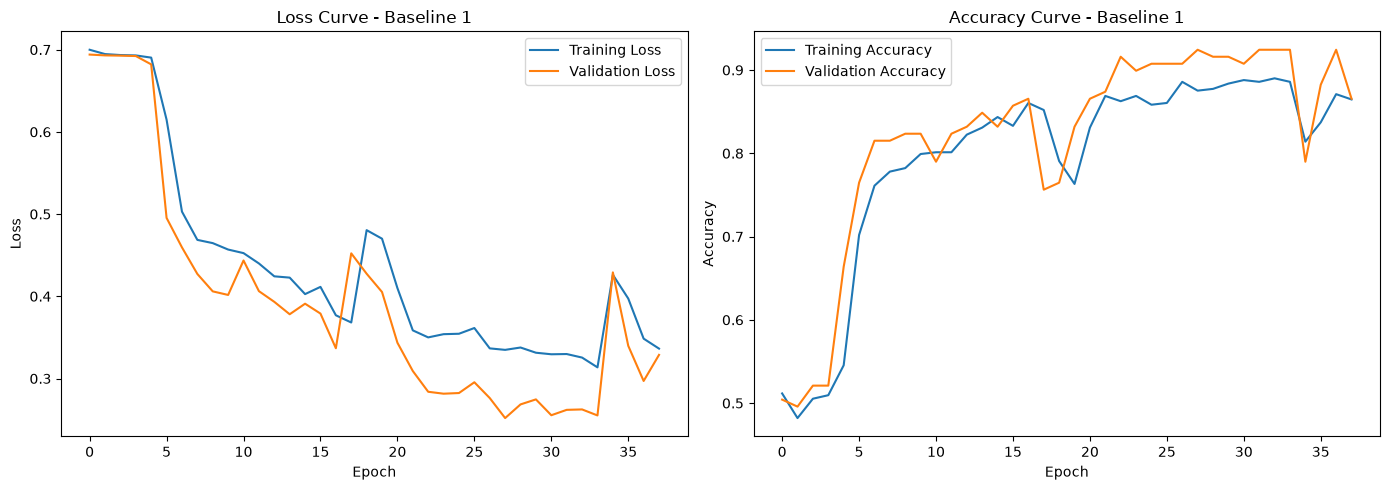

Confusion matrix saved to: learning_curves\confusion_matrix_Baseline_1.png


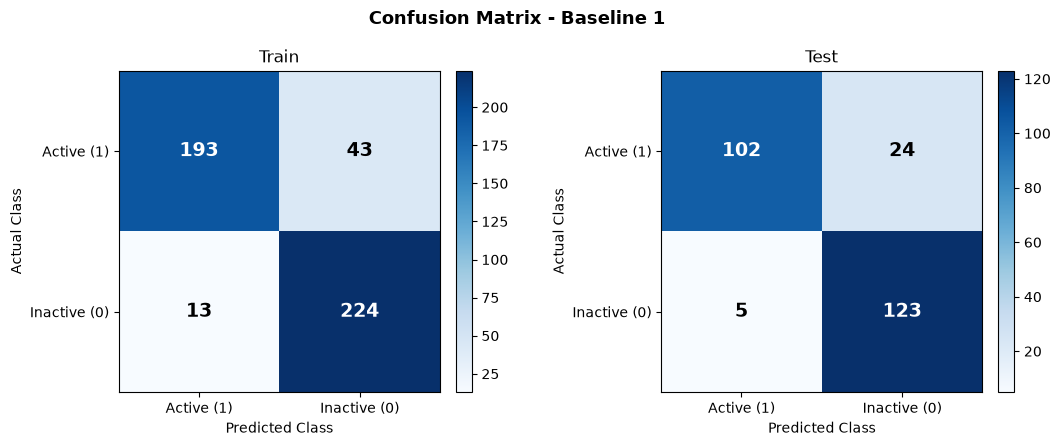

>>> Evaluation Baseline 1 on Train <<<
Accuracy  : 0.8816
Recall    : 0.8178
Precision : 0.9369
F1-Score  : 0.8733
>>> Evaluation Baseline 1 on Test <<<
Accuracy  : 0.8858
Recall    : 0.8095
Precision : 0.9533
F1-Score  : 0.8755
TRAINING | Baseline 2 | LSTM layers: [64, 128]
Learning curve saved to: learning_curves\learning_curve_Baseline_2.png


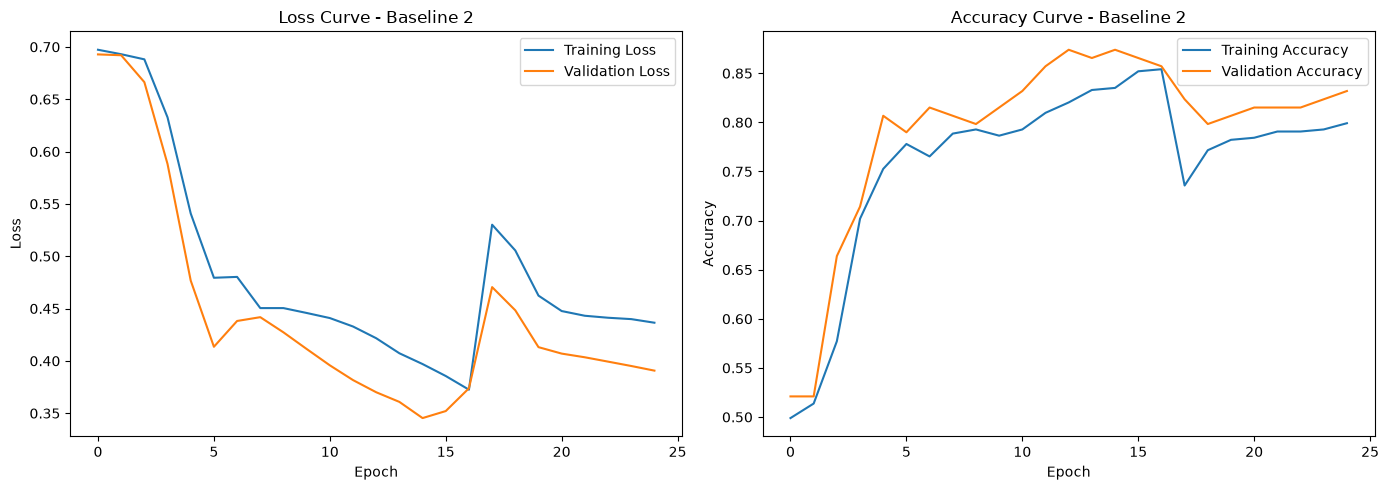

Confusion matrix saved to: learning_curves\confusion_matrix_Baseline_2.png


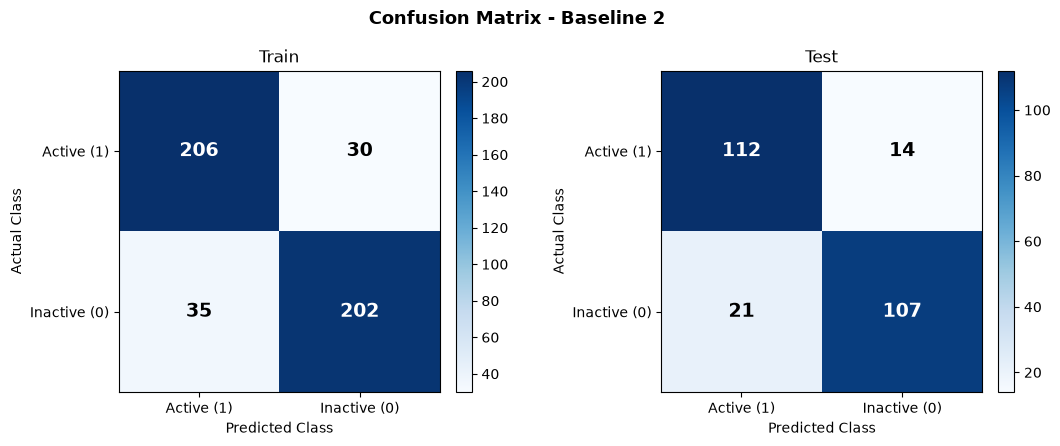

>>> Evaluation Baseline 2 on Train <<<
Accuracy  : 0.8626
Recall    : 0.8729
Precision : 0.8548
F1-Score  : 0.8637
>>> Evaluation Baseline 2 on Test <<<
Accuracy  : 0.8622
Recall    : 0.8889
Precision : 0.8421
F1-Score  : 0.8649
TRAINING | Baseline 3 | LSTM layers: [64, 128, 256]
Learning curve saved to: learning_curves\learning_curve_Baseline_3.png


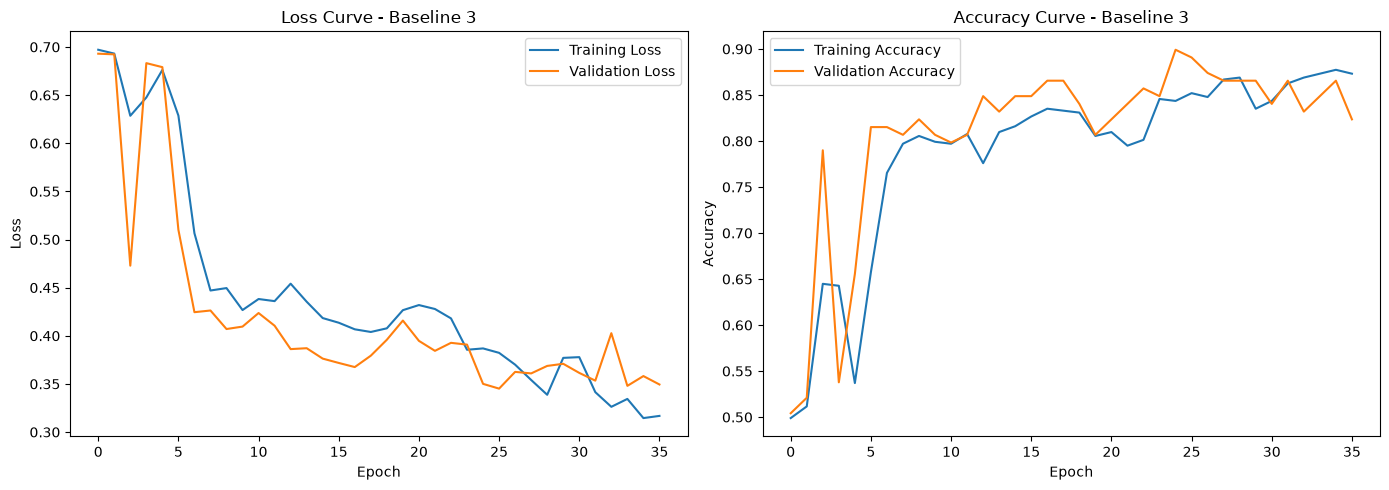

Confusion matrix saved to: learning_curves\confusion_matrix_Baseline_3.png


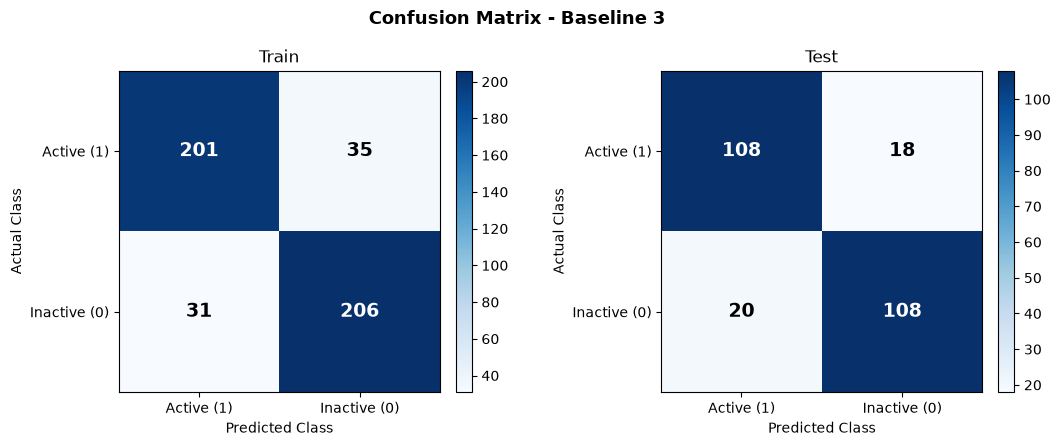

>>> Evaluation Baseline 3 on Train <<<
Accuracy  : 0.8605
Recall    : 0.8517
Precision : 0.8664
F1-Score  : 0.8590
>>> Evaluation Baseline 3 on Test <<<
Accuracy  : 0.8504
Recall    : 0.8571
Precision : 0.8437
F1-Score  : 0.8504


In [11]:
final_baseline_nets = {}
baseline_histories = {}
baseline_eval_results = {}

for name, units_list in baseline_configs.items():
    print("="*60)
    print(f"TRAINING | {name} | LSTM layers: {units_list}")
    print("="*60)

    net = build_skorch_net_with_history(
        units_list, X_val, Y_val,
        vocab_size=vocab_size, epochs=100, lr=0.001, batch_size=32,
        checkpoint_dir=f"checkpoints/baseline_{name.replace(' ', '_')}"
    )
    net.fit(X_tr, Y_tr)

    final_baseline_nets[name] = net
    history = {
        "loss": [row["train_loss"] for row in net.history],
        "val_loss": [row["valid_loss"] for row in net.history],
        "accuracy": [row["train_acc"] for row in net.history],
        "val_accuracy": [row["valid_acc"] for row in net.history],
    }
    baseline_histories[name] = history
    plot_learning_curve(history, model_name=name)

    # Evaluate on Train
    y_pred_train = net.predict(X_tr)
    TP_tr, TN_tr, FP_tr, FN_tr = compute_confusion_matrix(Y_tr, y_pred_train)
    metrics_train = compute_metrics(TP_tr, TN_tr, FP_tr, FN_tr)

    # Evaluate on Test
    y_pred_test = net.predict(X_test_int)
    TP_te, TN_te, FP_te, FN_te = compute_confusion_matrix(Y_test_int, y_pred_test)
    metrics_test = compute_metrics(TP_te, TN_te, FP_te, FN_te)

    plot_confusion_matrix_combined(TP_tr, TN_tr, FP_tr, FN_tr,
                                    TP_te, TN_te, FP_te, FN_te,
                                    model_name=name, save_dir=SAVE_DIR)

    print(f">>> Evaluation {name} on Train <<<")
    print(f"Accuracy  : {metrics_train['accuracy']:.4f}")
    print(f"Recall    : {metrics_train['recall']:.4f}")
    print(f"Precision : {metrics_train['precision']:.4f}")
    print(f"F1-Score  : {metrics_train['f1_score']:.4f}")

    print(f">>> Evaluation {name} on Test <<<")
    print(f"Accuracy  : {metrics_test['accuracy']:.4f}")
    print(f"Recall    : {metrics_test['recall']:.4f}")
    print(f"Precision : {metrics_test['precision']:.4f}")
    print(f"F1-Score  : {metrics_test['f1_score']:.4f}")

    baseline_eval_results[name] = {"train": metrics_train, "test": metrics_test}

# Ringkasan Hasil Training Baseline ke Satu DataFrame

In [12]:
train_summary_rows = []
test_summary_rows = []

for name, units_list in baseline_configs.items():
    metrics_train = baseline_eval_results[name]["train"]
    metrics_test = baseline_eval_results[name]["test"]

    train_summary_rows.append({
        "Configuration": name,
        "Number of LSTM Layers": len(units_list),
        "Units per Layer": str(tuple(units_list)),
        "Accuracy": metrics_train["accuracy"],
        "Recall": metrics_train["recall"],
        "Precision": metrics_train["precision"],
        "F1-Score": metrics_train["f1_score"],
        "TP": metrics_train["TP"],
        "TN": metrics_train["TN"],
        "FP": metrics_train["FP"],
        "FN": metrics_train["FN"],
    })

    test_summary_rows.append({
        "Configuration": name,
        "Number of LSTM Layers": len(units_list),
        "Units per Layer": str(tuple(units_list)),
        "Accuracy": metrics_test["accuracy"],
        "Recall": metrics_test["recall"],
        "Precision": metrics_test["precision"],
        "F1-Score": metrics_test["f1_score"],
        "TP": metrics_test["TP"],
        "TN": metrics_test["TN"],
        "FP": metrics_test["FP"],
        "FN": metrics_test["FN"],
    })

train_summary_df = pd.DataFrame(train_summary_rows).set_index("Configuration")
test_summary_df = pd.DataFrame(test_summary_rows).set_index("Configuration")

print("=== Baseline Summary - TRAIN ===")
display(train_summary_df)

print("\n=== Baseline Summary - TEST ===")
display(test_summary_df)

=== Baseline Summary - TRAIN ===


,Number of LSTM Layers,Units per Layer,Accuracy,Recall,Precision,F1-Score,TP,TN,FP,FN
Configuration,,,,,,,,,,
Baseline 1,1,"(64,)",0.881607,0.817797,0.936893,0.873303,193,224,13,43
Baseline 2,2,"(64, 128)",0.862579,0.872881,0.854772,0.863732,206,202,35,30
Baseline 3,3,"(64, 128, 256)",0.860465,0.851695,0.866379,0.858974,201,206,31,35



=== Baseline Summary - TEST ===


,Number of LSTM Layers,Units per Layer,Accuracy,Recall,Precision,F1-Score,TP,TN,FP,FN
Configuration,,,,,,,,,,
Baseline 1,1,"(64,)",0.885827,0.809524,0.953271,0.875536,102,123,5,24
Baseline 2,2,"(64, 128)",0.862205,0.888889,0.842105,0.864865,112,107,21,14
Baseline 3,3,"(64, 128, 256)",0.850394,0.857143,0.843750,0.850394,108,108,20,18


# Parameter Monarch Butterfly Optimization (MBO)

In [13]:
mbo_params_table = pd.DataFrame([
    {"Parameter": "Population Size (NP)", "Value": 10},
    {"Parameter": "Migration Ratio (p)", "Value": "[0.1, 0.25, 0.5]"},
    {"Parameter": "Max Step (Smax)", "Value": 1.0},
    {"Parameter": "Scale Factor (alpha)", "Value": "alpha_t = Smax / t^2 (Equation 11)"},
    {"Parameter": "Max Iterations", "Value": 10},
]).set_index("Parameter")

display(mbo_params_table)

,Value
Parameter,
Population Size (NP),10
Migration Ratio (p),"[0.1, 0.25, 0.5]"
Max Step (Smax),1.0
Scale Factor (alpha),alpha_t = Smax / t^2 (Equation 11)
Max Iterations,10


# Skema optimasi MBO

In [14]:
mbo_schemes = {
    "MBO 1": {"p": 0.1},
    "MBO 2": {"p": 0.25},
    "MBO 3": {"p": 0.5},
}

mbo_schemes_table = pd.DataFrame([
    {"Scheme": name, "Migration Ratio (p)": cfg["p"]}
    for name, cfg in mbo_schemes.items()
]).set_index("Scheme")

display(mbo_schemes_table)

,Migration Ratio (p)
Scheme,
MBO 1,0.10
MBO 2,0.25
MBO 3,0.50


# Definisi ruang pencarian Hyperparameter LSTM

In [15]:
# Assumption note: MBO optimizes the number of nodes per LSTM layer (3 layers).
# The learning rate is NOT optimized; it uses a fixed value (FIXED_LR).

DIM = 3  # number of decision variables: units_layer1, units_layer2, units_layer3

BOUNDS = np.array([
    [16, 128],     # units layer 1
    [32, 256],     # units layer 2
    [64, 512],     # units layer 3
])

FIXED_LR = 0.001

def decode_solution(vector):
    """Convert the MBO continuous vector into valid LSTM hyperparameters."""
    units1 = int(np.clip(round(vector[0]), BOUNDS[0, 0], BOUNDS[0, 1]))
    units2 = int(np.clip(round(vector[1]), BOUNDS[1, 0], BOUNDS[1, 1]))
    units3 = int(np.clip(round(vector[2]), BOUNDS[2, 0], BOUNDS[2, 1]))
    return {"units_list": [units1, units2, units3], "lr": FIXED_LR}

# Fitness Function

In [16]:
import tempfile

def fitness_function(vector, X_tr, Y_tr, X_val, Y_val, vocab_size, epochs=100, batch_size=32,
                      best_tracker=None, model_save_path=None):
    """
    Fitness = BEST validation loss across the training run.
    Early stopping (patience=10) menghentikan run kalau valid_loss nggak membaik,
    jadi setiap individu nggak wajib jalan penuh sampai `epochs`.
    Weights dipulihkan ke epoch terbaik (load_best=True) sebelum scoring/saving,
    jadi model yang disimpan sesuai fitness yang dilaporkan — bukan epoch terakhir yang overfit.
    """
    config = decode_solution(vector)
    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.long),
        torch.tensor(Y_val, dtype=torch.long)
    )

    tmp_dir = tempfile.mkdtemp()
    cp = Checkpoint(
        monitor="valid_loss_best",
        dirname=tmp_dir,
        f_params="best_params.pt",
        f_optimizer=None,
        f_criterion=None,
        f_history=None,
        load_best=True,
    )

    net = NeuralNetClassifier(
        module=LSTMBaselineSkorch,
        module__vocab_size=vocab_size,
        module__embedding_dim=50,
        module__units_list=config["units_list"],
        max_epochs=epochs,
        lr=config["lr"],
        optimizer=torch.optim.Adam,
        criterion=nn.CrossEntropyLoss,
        batch_size=batch_size,
        device=device,
        train_split=predefined_split(val_dataset),
        callbacks=[
            ("train_acc", EpochScoring(scoring="accuracy", on_train=True, name="train_acc", lower_is_better=False)),
            ("checkpoint", cp),
            ("early_stop", EarlyStopping(monitor="valid_loss", patience=10, lower_is_better=True)),
        ],
        verbose=0
    )
    try:
        net.fit(X_tr, Y_tr)  # net sekarang membawa bobot epoch TERBAIK, bukan epoch terakhir
        val_loss = min(row["valid_loss"] for row in net.history)

        if best_tracker is not None and val_loss < best_tracker["best_loss"]:
            best_tracker["best_loss"] = val_loss
            best_tracker["best_config"] = config
            best_tracker["best_history"] = {
                "loss": [row["train_loss"] for row in net.history],
                "val_loss": [row["valid_loss"] for row in net.history],
                "accuracy": [row["train_acc"] for row in net.history],
                "val_accuracy": [row["valid_acc"] for row in net.history],
            }
            if model_save_path is not None:
                net.save_params(f_params=model_save_path)
                print(f"  -> New best model found (val_loss={val_loss:.4f}), saved to: {model_save_path}")

        shutil.rmtree(tmp_dir, ignore_errors=True)
        return val_loss
    except Exception as e:
        shutil.rmtree(tmp_dir, ignore_errors=True)
        print(f"Evaluation failed for configuration {config}: {e}")
        return float("inf")

# Implementasi Algoritma MBO

In [17]:
def initialize_population(NP, dim, bounds):
    population = np.zeros((NP, dim))
    for d in range(dim):
        population[:, d] = np.random.uniform(bounds[d, 0], bounds[d, 1], NP)
    return population


def migration_operator(subpop1, subpop2, p, dim):
    """Migration operator: subpop1 individuals are updated based on subpop1 or subpop2."""
    NP1 = len(subpop1)
    new_subpop1 = np.copy(subpop1)

    for i in range(NP1):
        for d in range(dim):
            r = np.random.uniform(0, 1) * 1.0  # multiplied by migration period (assumed = 1.0)
            if r <= p:
                r1 = np.random.randint(0, NP1)
                new_subpop1[i, d] = subpop1[r1, d]
            else:
                r2 = np.random.randint(0, len(subpop2))
                new_subpop1[i, d] = subpop2[r2, d]

    return new_subpop1


def butterfly_adjusting_operator(subpop2, best_solution, alpha_t, p, BAR, dim):
    """Butterfly adjusting operator: subpop2 individuals are updated toward the best solution."""
    NP2 = len(subpop2)
    new_subpop2 = np.copy(subpop2)

    for i in range(NP2):
        for d in range(dim):
            if np.random.uniform(0, 1) <= p:
                new_subpop2[i, d] = best_solution[d]
            else:
                r3 = np.random.randint(0, NP2)
                new_subpop2[i, d] = subpop2[r3, d]

                if np.random.uniform(0, 1) > BAR:
                    dx = levy_step(dim)
                    new_subpop2[i, d] += alpha_t * (dx[d] - 0.5)

    return new_subpop2


def levy_step(dim, beta=1.5):
    """Random walk based on Levy flight, used in the butterfly adjusting operator."""
    sigma = (math.gamma(1 + beta) * np.sin(np.pi * beta / 2) /
             (math.gamma((1 + beta) / 2) * beta * (2 ** ((beta - 1) / 2)))) ** (1 / beta)
    u = np.random.normal(0, sigma, dim)
    v = np.random.normal(0, 1, dim)
    step = u / (np.abs(v) ** (1 / beta))
    return step


def clip_to_bounds(population, bounds):
    for d in range(bounds.shape[0]):
        population[:, d] = np.clip(population[:, d], bounds[d, 0], bounds[d, 1])
    return population

# Fungsi utama MBO

In [18]:
def run_mbo(p, X_tr, Y_tr, X_val, Y_val, vocab_size, NP=10, max_iter=10, Smax=1.0, BAR=5/12,
            dim=DIM, bounds=BOUNDS, fitness_epochs=100, scheme_name="",
            best_tracker=None, model_save_path=None):

    NP1 = int(np.ceil(p * NP))
    NP2 = NP - NP1

    population = initialize_population(NP, dim, bounds)

    print(f"[{scheme_name}] Evaluating initial population ({NP} individuals)...")
    fitness = np.zeros(NP)
    for i, ind in enumerate(population):
        fitness[i] = fitness_function(ind, X_tr, Y_tr, X_val, Y_val, vocab_size,
                                       epochs=fitness_epochs,
                                       best_tracker=best_tracker, model_save_path=model_save_path)
        print(f"[{scheme_name}] Individual {i+1}/{NP} evaluated - fitness (loss): {fitness[i]:.4f}")

    best_idx = np.argmin(fitness)
    best_solution = population[best_idx].copy()
    best_fitness = fitness[best_idx]

    convergence_curve = [best_fitness]

    for t in range(1, max_iter + 1):
        alpha_t = Smax / (t ** 2)

        sorted_idx = np.argsort(fitness)
        population = population[sorted_idx]
        fitness = fitness[sorted_idx]

        subpop1 = population[:NP1]
        subpop2 = population[NP1:]

        new_subpop1 = migration_operator(subpop1, subpop2, p, dim)
        new_subpop2 = butterfly_adjusting_operator(subpop2, best_solution, alpha_t, p, BAR, dim)

        new_population = np.vstack([new_subpop1, new_subpop2])
        new_population = clip_to_bounds(new_population, bounds)

        print(f"[{scheme_name}] Iteration {t}/{max_iter} - evaluating {NP} new individuals...")
        new_fitness = np.zeros(NP)
        for i, ind in enumerate(new_population):
            new_fitness[i] = fitness_function(ind, X_tr, Y_tr, X_val, Y_val, vocab_size,
                                               epochs=fitness_epochs,
                                               best_tracker=best_tracker, model_save_path=model_save_path)
            print(f"[{scheme_name}] Iteration {t} - Individual {i+1}/{NP} evaluated - fitness (loss): {new_fitness[i]:.4f}")

        combined_population = np.vstack([population, new_population])
        combined_fitness = np.concatenate([fitness, new_fitness])

        best_indices = np.argsort(combined_fitness)[:NP]
        population = combined_population[best_indices]
        fitness = combined_fitness[best_indices]

        if fitness[0] < best_fitness:
            best_fitness = fitness[0]
            best_solution = population[0].copy()

        convergence_curve.append(best_fitness)
        print(f"[{scheme_name}] Iteration {t}/{max_iter} DONE - Best Fitness (Loss): {best_fitness:.4f}")

    return best_solution, best_fitness, convergence_curve

# Jalankan MBO untuk ketiga skema

In [19]:

BEST_MODEL_DIR = os.path.join(SAVE_DIR, "best_models")
os.makedirs(BEST_MODEL_DIR, exist_ok=True)

mbo_results = {}

for scheme_name, cfg in mbo_schemes.items():
    print("="*60)
    print(f"RUNNING {scheme_name} | Migration Ratio (p) = {cfg['p']}")
    print("="*60)

    safe_name = scheme_name.replace(" ", "_")
    model_save_path = os.path.join(BEST_MODEL_DIR, f"{safe_name}_best_params.pt")
    best_tracker = {"best_loss": float("inf"), "best_config": None, "best_history": None}

    best_solution, best_fitness, convergence_curve = run_mbo(
        p=cfg["p"],
        X_tr=X_tr, Y_tr=Y_tr,
        X_val=X_val, Y_val=Y_val,
        vocab_size=vocab_size,
        NP=10,
        max_iter=10,
        Smax=1.0,
        fitness_epochs=100,
        scheme_name=scheme_name,
        best_tracker=best_tracker,
        model_save_path=model_save_path,
    )

    mbo_results[scheme_name] = {
        "best_solution": best_solution,
        "best_fitness": best_fitness,
        "convergence_curve": convergence_curve,
        "best_config": decode_solution(best_solution),
        "best_history": best_tracker["best_history"],   # captured live during the search
        "model_save_path": model_save_path,
    }

    print(f"\n{scheme_name} DONE | Best Loss (Validation): {best_fitness:.4f}")
    print(f"Best configuration: {mbo_results[scheme_name]['best_config']}")
    print(f"Best model saved to: {model_save_path}")

RUNNING MBO 1 | Migration Ratio (p) = 0.1
[MBO 1] Evaluating initial population (10 individuals)...
  -> New best model found (val_loss=0.2724), saved to: learning_curves\best_models\MBO_1_best_params.pt
[MBO 1] Individual 1/10 evaluated - fitness (loss): 0.2724
[MBO 1] Individual 2/10 evaluated - fitness (loss): 0.3033
  -> New best model found (val_loss=0.2395), saved to: learning_curves\best_models\MBO_1_best_params.pt
[MBO 1] Individual 3/10 evaluated - fitness (loss): 0.2395
  -> New best model found (val_loss=0.2223), saved to: learning_curves\best_models\MBO_1_best_params.pt
[MBO 1] Individual 4/10 evaluated - fitness (loss): 0.2223
[MBO 1] Individual 5/10 evaluated - fitness (loss): 0.2765
[MBO 1] Individual 6/10 evaluated - fitness (loss): 0.2364
[MBO 1] Individual 7/10 evaluated - fitness (loss): 0.2794
[MBO 1] Individual 8/10 evaluated - fitness (loss): 0.6278
[MBO 1] Individual 9/10 evaluated - fitness (loss): 0.6274
[MBO 1] Individual 10/10 evaluated - fitness (loss): 0.28

# Plot Kurva Konvergensi ketiga skema MBO

Convergence curve saved to: learning_curves\mbo_convergence_curve.png


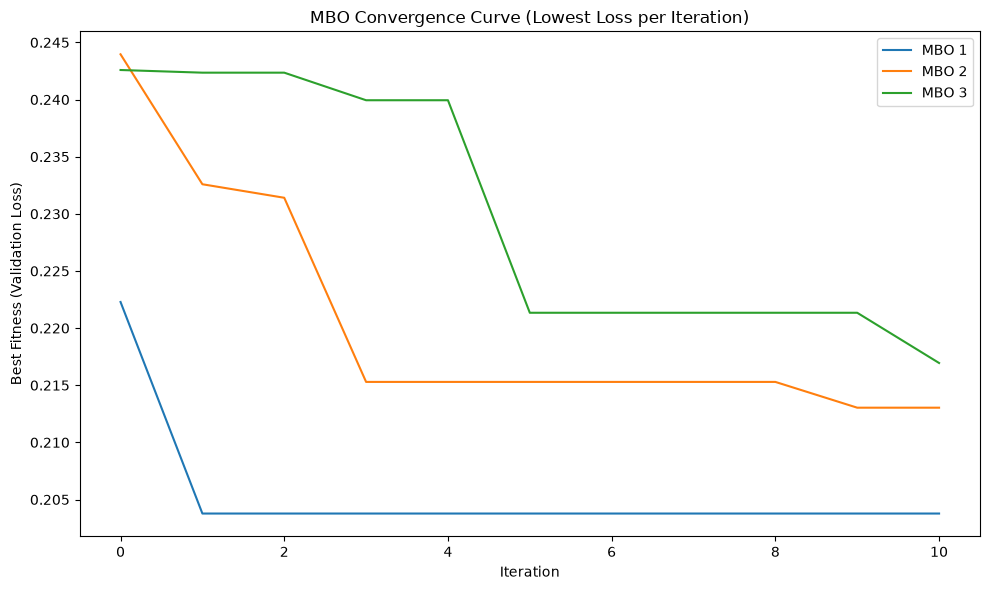

In [20]:
plt.figure(figsize=(10, 6))

for scheme_name, result in mbo_results.items():
    plt.plot(result["convergence_curve"], label=scheme_name)

plt.title("MBO Convergence Curve (Lowest Loss per Iteration)")
plt.xlabel("Iteration")
plt.ylabel("Best Fitness (Validation Loss)")
plt.legend()
plt.tight_layout()

save_path = os.path.join(SAVE_DIR, "mbo_convergence_curve.png")
plt.savefig(save_path, dpi=150)
print(f"Convergence curve saved to: {save_path}")
plt.show()

# Ringkasan Hasil MBO

In [21]:
mbo_summary_rows = []

for scheme_name, result in mbo_results.items():
    config = result["best_config"]
    mbo_summary_rows.append({
        "Scheme": scheme_name,
        "Migration Ratio (p)": mbo_schemes[scheme_name]["p"],
        "Units Layer 1": config["units_list"][0],
        "Units Layer 2": config["units_list"][1],
        "Units Layer 3": config["units_list"][2],
        "Learning Rate": config["lr"],
        "Best Loss (Validation)": result["best_fitness"],
    })

mbo_summary_df = pd.DataFrame(mbo_summary_rows).set_index("Scheme")
display(mbo_summary_df)

,Migration Ratio (p),Units Layer 1,Units Layer 2,Units Layer 3,Learning Rate,Best Loss (Validation)
Scheme,,,,,,
MBO 1,0.10,23,218,195,0.001,0.203773
MBO 2,0.25,67,103,468,0.001,0.213036
MBO 3,0.50,40,144,301,0.001,0.216947


# Evaluasi MBO

FINAL MODEL | MBO 1 | Configuration: {'units_list': [23, 218, 195], 'lr': 0.001}
Retrain di Train+Val gabungan | 42 epoch (fixed, sesuai hasil search)
Confusion matrix saved to: learning_curves\confusion_matrix_MBO_(MBO_1).png


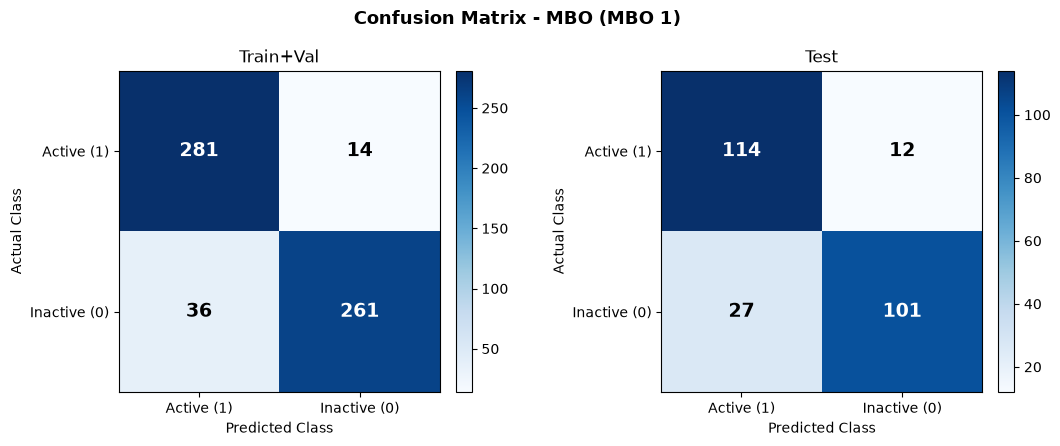

>>> Evaluation MBO (MBO 1) on Train+Val <<<
Accuracy  : 0.9155
Recall    : 0.9525
Precision : 0.8864
F1-Score  : 0.9183
>>> Evaluation MBO (MBO 1) on Holdout Test <<<
Accuracy  : 0.8465
Recall    : 0.9048
Precision : 0.8085
F1-Score  : 0.8539
FINAL MODEL | MBO 2 | Configuration: {'units_list': [67, 103, 468], 'lr': 0.001}
Retrain di Train+Val gabungan | 41 epoch (fixed, sesuai hasil search)
Confusion matrix saved to: learning_curves\confusion_matrix_MBO_(MBO_2).png


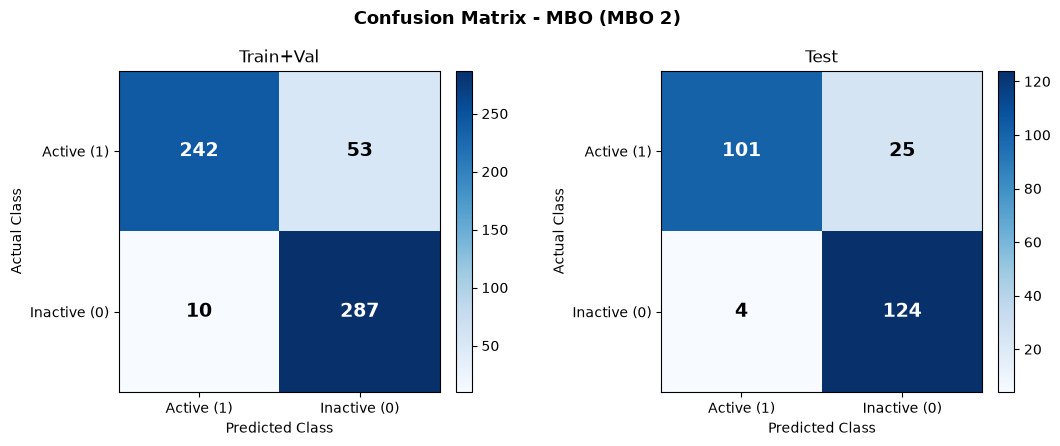

>>> Evaluation MBO (MBO 2) on Train+Val <<<
Accuracy  : 0.8936
Recall    : 0.8203
Precision : 0.9603
F1-Score  : 0.8848
>>> Evaluation MBO (MBO 2) on Holdout Test <<<
Accuracy  : 0.8858
Recall    : 0.8016
Precision : 0.9619
F1-Score  : 0.8745
FINAL MODEL | MBO 3 | Configuration: {'units_list': [40, 144, 301], 'lr': 0.001}
Retrain di Train+Val gabungan | 43 epoch (fixed, sesuai hasil search)
Confusion matrix saved to: learning_curves\confusion_matrix_MBO_(MBO_3).png


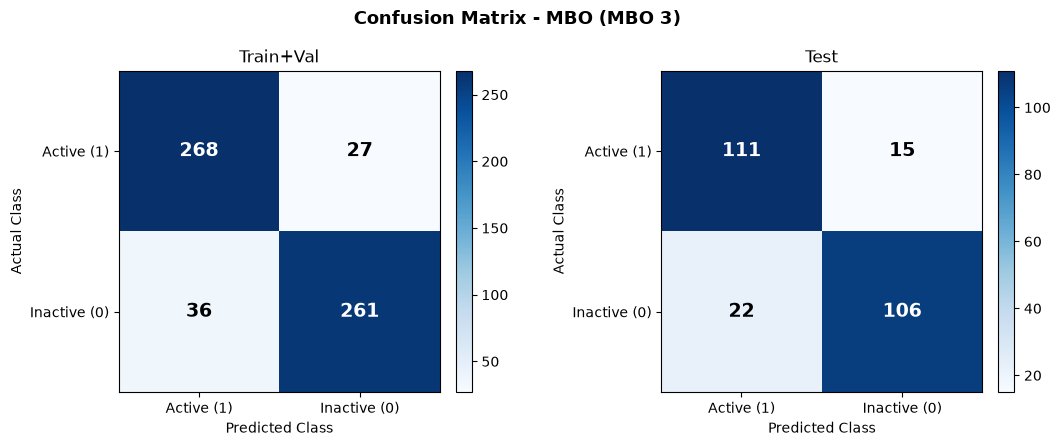

>>> Evaluation MBO (MBO 3) on Train+Val <<<
Accuracy  : 0.8936
Recall    : 0.9085
Precision : 0.8816
F1-Score  : 0.8948
>>> Evaluation MBO (MBO 3) on Holdout Test <<<
Accuracy  : 0.8543
Recall    : 0.8810
Precision : 0.8346
F1-Score  : 0.8571


In [22]:
final_mbo_nets = {}
mbo_histories = {}
mbo_eval_results = {}

X_trainval = np.concatenate([X_tr, X_val], axis=0)
Y_trainval = np.concatenate([Y_tr, Y_val], axis=0)

for scheme_name, result in mbo_results.items():
    config = result["best_config"]
    best_history = result["best_history"]
    best_epoch = int(np.argmin(best_history["val_loss"])) + 1  # titik terbaik saat MBO search

    print("="*60)
    print(f"FINAL MODEL | {scheme_name} | Configuration: {config}")
    print(f"Retrain di Train+Val gabungan | {best_epoch} epoch (fixed, sesuai hasil search)")
    print("="*60)

    net = NeuralNetClassifier(
        module=LSTMBaselineSkorch,
        module__vocab_size=vocab_size,
        module__embedding_dim=50,
        module__units_list=config["units_list"],
        max_epochs=best_epoch,
        lr=config["lr"],
        optimizer=torch.optim.Adam,
        criterion=nn.CrossEntropyLoss,
        batch_size=32,
        device=device,
        train_split=None, 
        callbacks=[("train_acc", EpochScoring(scoring="accuracy", on_train=True, name="train_acc", lower_is_better=False))],
        verbose=0
    )
    net.fit(X_trainval, Y_trainval)

    final_mbo_nets[scheme_name] = net
    mbo_histories[scheme_name] = {
        "loss": [row["train_loss"] for row in net.history],
        "accuracy": [row["train_acc"] for row in net.history],
    }

    y_pred_train = net.predict(X_trainval)
    TP_tr, TN_tr, FP_tr, FN_tr = compute_confusion_matrix(Y_trainval, y_pred_train)
    metrics_train = compute_metrics(TP_tr, TN_tr, FP_tr, FN_tr)

    y_pred_test = net.predict(X_test_int)
    TP_te, TN_te, FP_te, FN_te = compute_confusion_matrix(Y_test_int, y_pred_test)
    metrics_test = compute_metrics(TP_te, TN_te, FP_te, FN_te)


    plot_confusion_matrix_combined(TP_tr, TN_tr, FP_tr, FN_tr,
                                    TP_te, TN_te, FP_te, FN_te,
                                    model_name=f"MBO ({scheme_name})", save_dir=SAVE_DIR,
                                    train_label="Train+Val")

    print(f">>> Evaluation MBO ({scheme_name}) on Train+Val <<<")
    print(f"Accuracy  : {metrics_train['accuracy']:.4f}")
    print(f"Recall    : {metrics_train['recall']:.4f}")
    print(f"Precision : {metrics_train['precision']:.4f}")
    print(f"F1-Score  : {metrics_train['f1_score']:.4f}")

    print(f">>> Evaluation MBO ({scheme_name}) on Holdout Test <<<")
    print(f"Accuracy  : {metrics_test['accuracy']:.4f}")
    print(f"Recall    : {metrics_test['recall']:.4f}")
    print(f"Precision : {metrics_test['precision']:.4f}")
    print(f"F1-Score  : {metrics_test['f1_score']:.4f}")

    mbo_eval_results[scheme_name] = {"train": metrics_train, "test": metrics_test}

# Rekap Evaluasi MBO

In [23]:
mbo_train_summary_rows = []
mbo_test_summary_rows = []

for scheme_name, result in mbo_results.items():
    config = result["best_config"]
    metrics_train = mbo_eval_results[scheme_name]["train"]
    metrics_test = mbo_eval_results[scheme_name]["test"]

    mbo_train_summary_rows.append({
        "Scheme": scheme_name,
        "Units Layer 1": config["units_list"][0],
        "Units Layer 2": config["units_list"][1],
        "Units Layer 3": config["units_list"][2],
        "Accuracy": metrics_train["accuracy"],
        "Recall": metrics_train["recall"],
        "Precision": metrics_train["precision"],
        "F1-Score": metrics_train["f1_score"],
        "TP": metrics_train["TP"],
        "TN": metrics_train["TN"],
        "FP": metrics_train["FP"],
        "FN": metrics_train["FN"],
    })

    mbo_test_summary_rows.append({
        "Scheme": scheme_name,
        "Units Layer 1": config["units_list"][0],
        "Units Layer 2": config["units_list"][1],
        "Units Layer 3": config["units_list"][2],
        "Accuracy": metrics_test["accuracy"],
        "Recall": metrics_test["recall"],
        "Precision": metrics_test["precision"],
        "F1-Score": metrics_test["f1_score"],
        "TP": metrics_test["TP"],
        "TN": metrics_test["TN"],
        "FP": metrics_test["FP"],
        "FN": metrics_test["FN"],
    })

mbo_train_summary_df = pd.DataFrame(mbo_train_summary_rows).set_index("Scheme")
mbo_test_summary_df = pd.DataFrame(mbo_test_summary_rows).set_index("Scheme")

print("=== MBO Evaluation Summary - TRAIN+VAL ===")
display(mbo_train_summary_df)

print("\n=== MBO Evaluation Summary - TEST ===")
display(mbo_test_summary_df)

=== MBO Evaluation Summary - TRAIN+VAL ===


,Units Layer 1,Units Layer 2,Units Layer 3,Accuracy,Recall,Precision,F1-Score,TP,TN,FP,FN
Scheme,,,,,,,,,,,
MBO 1,23,218,195,0.915541,0.952542,0.886435,0.918301,281,261,36,14
MBO 2,67,103,468,0.893581,0.820339,0.960317,0.884826,242,287,10,53
MBO 3,40,144,301,0.893581,0.908475,0.881579,0.894825,268,261,36,27



=== MBO Evaluation Summary - TEST ===


,Units Layer 1,Units Layer 2,Units Layer 3,Accuracy,Recall,Precision,F1-Score,TP,TN,FP,FN
Scheme,,,,,,,,,,,
MBO 1,23,218,195,0.846457,0.904762,0.808511,0.853933,114,101,27,12
MBO 2,67,103,468,0.885827,0.801587,0.961905,0.874459,101,124,4,25
MBO 3,40,144,301,0.854331,0.880952,0.834586,0.857143,111,106,22,15


# Skema MBO Terbaik 

In [24]:
best_scheme_name = mbo_summary_df["Best Loss (Validation)"].idxmin()
best_metrics_test = mbo_eval_results[best_scheme_name]["test"]

print(f"Best MBO scheme: {best_scheme_name}")
print(f"Configuration: {mbo_results[best_scheme_name]['best_config']}")
print(f"Validation Loss: {mbo_summary_df.loc[best_scheme_name, 'Best Loss (Validation)']:.4f}")
print(f"\n>>> Holdout Test Results <<<")
print(f"Accuracy  : {best_metrics_test['accuracy']:.4f}")
print(f"Recall    : {best_metrics_test['recall']:.4f}")
print(f"Precision : {best_metrics_test['precision']:.4f}")
print(f"F1-Score  : {best_metrics_test['f1_score']:.4f}")

Best MBO scheme: MBO 1
Configuration: {'units_list': [23, 218, 195], 'lr': 0.001}
Validation Loss: 0.2038

>>> Holdout Test Results <<<
Accuracy  : 0.8465
Recall    : 0.9048
Precision : 0.8085
F1-Score  : 0.8539


# Perbandingan Hyperparameter Tuning: Baseline (Manual) vs MBO (Metaheuristik)

,Type,Val Loss (best),Test Accuracy,Test F1
Model,,,,
Baseline 1,Manual (No Tuning),0.251882,0.885827,0.875536
Baseline 2,Manual (No Tuning),0.345375,0.862205,0.864865
Baseline 3,Manual (No Tuning),0.345135,0.850394,0.850394
MBO 1,MBO (Tuned),0.203773,0.846457,0.853933
MBO 2,MBO (Tuned),0.213036,0.885827,0.874459
MBO 3,MBO (Tuned),0.216947,0.854331,0.857143


Comparison chart saved to: learning_curves\baseline_vs_mbo_comparison.png


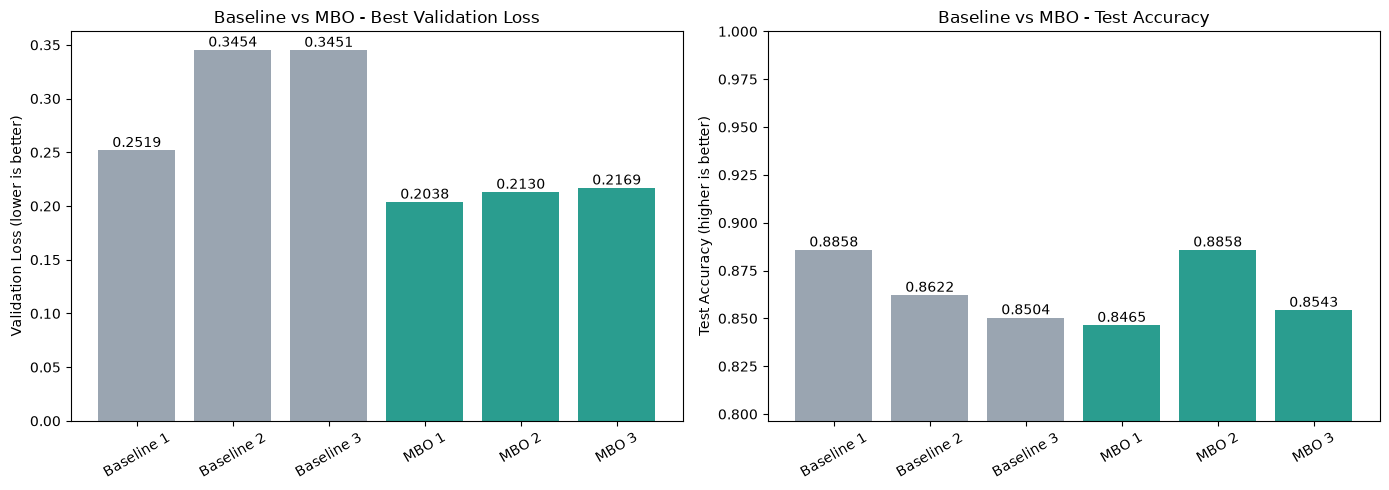

In [25]:
comparison_rows = []

# All manual baselines (not just the one with the lowest final val_loss)
for name, units_list in baseline_configs.items():
    comparison_rows.append({
        "Model": name,
        "Type": "Manual (No Tuning)",
        "Val Loss (best)": min(baseline_histories[name]["val_loss"]),
        "Test Accuracy": baseline_eval_results[name]["test"]["accuracy"],
        "Test F1": baseline_eval_results[name]["test"]["f1_score"],
    })

# All MBO schemes
for scheme_name, result in mbo_results.items():
    comparison_rows.append({
        "Model": scheme_name,
        "Type": "MBO (Tuned)",
        "Val Loss (best)": result["best_fitness"],
        "Test Accuracy": mbo_eval_results[scheme_name]["test"]["accuracy"],
        "Test F1": mbo_eval_results[scheme_name]["test"]["f1_score"],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# gray for manual baseline, green for MBO
colors = ["#9aa5b1"] * len(baseline_configs) + ["#2a9d8f"] * len(mbo_results)

axes[0].bar(comparison_df.index, comparison_df["Val Loss (best)"], color=colors)
axes[0].set_ylabel("Validation Loss (lower is better)")
axes[0].set_title("Baseline vs MBO - Best Validation Loss")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(comparison_df["Val Loss (best)"]):
    axes[0].text(i, v, f"{v:.4f}", ha="center", va="bottom")

axes[1].bar(comparison_df.index, comparison_df["Test Accuracy"], color=colors)
axes[1].set_ylabel("Test Accuracy (higher is better)")
axes[1].set_ylim(min(comparison_df["Test Accuracy"]) - 0.05, 1.0)
axes[1].set_title("Baseline vs MBO - Test Accuracy")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(comparison_df["Test Accuracy"]):
    axes[1].text(i, v, f"{v:.4f}", ha="center", va="bottom")

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, "baseline_vs_mbo_comparison.png")
plt.savefig(save_path, dpi=150)
print(f"Comparison chart saved to: {save_path}")
plt.show()

# Rekap Keseluruhan

In [26]:
RECAP_DIR = os.path.join(SAVE_DIR, "recap_tables")
os.makedirs(RECAP_DIR, exist_ok=True)

overall_rows = []

# --- Baseline rows ---
for name, units_list in baseline_configs.items():
    for dataset_name, metrics in [("Train", baseline_eval_results[name]["train"]),
                                   ("Test", baseline_eval_results[name]["test"])]:
        overall_rows.append({
            "Model": name,
            "Type": "Baseline (Manual)",
            "Dataset": dataset_name,
            "Architecture (Units per Layer)": str(tuple(units_list)),
            "Accuracy": metrics["accuracy"],
            "Recall": metrics["recall"],
            "Precision": metrics["precision"],
            "F1-Score": metrics["f1_score"],
            "TP": metrics["TP"],
            "TN": metrics["TN"],
            "FP": metrics["FP"],
            "FN": metrics["FN"],
        })

# --- MBO rows ---
for scheme_name, result in mbo_results.items():
    units_list = result["best_config"]["units_list"]
    for dataset_name, metrics in [("Train+Val", mbo_eval_results[scheme_name]["train"]),
                                ("Test", mbo_eval_results[scheme_name]["test"])]:
        overall_rows.append({
            "Model": scheme_name,
            "Type": "MBO (Tuned)",
            "Dataset": dataset_name,
            "Architecture (Units per Layer)": str(tuple(units_list)),
            "Accuracy": metrics["accuracy"],
            "Recall": metrics["recall"],
            "Precision": metrics["precision"],
            "F1-Score": metrics["f1_score"],
            "TP": metrics["TP"],
            "TN": metrics["TN"],
            "FP": metrics["FP"],
            "FN": metrics["FN"],
        })

overall_recap_df = pd.DataFrame(overall_rows)

# ==== Split into 4 separated tables: Baseline/MBO x Train/Test ====
baseline_train_recap_df = overall_recap_df[
    (overall_recap_df["Type"] == "Baseline (Manual)") & (overall_recap_df["Dataset"] == "Train")
].drop(columns=["Type", "Dataset"]).set_index("Model")

baseline_test_recap_df = overall_recap_df[
    (overall_recap_df["Type"] == "Baseline (Manual)") & (overall_recap_df["Dataset"] == "Test")
].drop(columns=["Type", "Dataset"]).set_index("Model")

mbo_train_recap_df = overall_recap_df[
    (overall_recap_df["Type"] == "MBO (Tuned)") & (overall_recap_df["Dataset"] == "Train+Val")
].drop(columns=["Type", "Dataset"]).set_index("Model")

mbo_test_recap_df = overall_recap_df[
    (overall_recap_df["Type"] == "MBO (Tuned)") & (overall_recap_df["Dataset"] == "Test")
].drop(columns=["Type", "Dataset"]).set_index("Model")

print("=== Overall Recap - Baseline (Train) ===")
display(baseline_train_recap_df)

print("\n=== Overall Recap - Baseline (Test) ===")
display(baseline_test_recap_df)

print("\n=== Overall Recap - MBO (Train+Val) ===")
display(mbo_train_recap_df)

print("\n=== Overall Recap - MBO (Test) ===")
display(mbo_test_recap_df)

# ==== Save each separated table to CSV ====
baseline_train_recap_df.to_csv(os.path.join(RECAP_DIR, "recap_baseline_train.csv"))
baseline_test_recap_df.to_csv(os.path.join(RECAP_DIR, "recap_baseline_test.csv"))
mbo_train_recap_df.to_csv(os.path.join(RECAP_DIR, "recap_mbo_trainval.csv"))
mbo_test_recap_df.to_csv(os.path.join(RECAP_DIR, "recap_mbo_test.csv"))

# ==== Save one combined "overall recap" CSV (long format, all in one) ====
overall_recap_df_indexed = overall_recap_df.set_index(["Type", "Dataset", "Model"])
overall_recap_df_indexed.to_csv(os.path.join(RECAP_DIR, "recap_overall_combined.csv"))

print(f"\nAll recap tables saved to: {RECAP_DIR}")
print(" - recap_baseline_train.csv")
print(" - recap_baseline_test.csv")
print(" - recap_mbo_trainval.csv")
print(" - recap_mbo_test.csv")
print(" - recap_overall_combined.csv (all models, all-in-one, long format)")

=== Overall Recap - Baseline (Train) ===


,Architecture (Units per Layer),Accuracy,Recall,Precision,F1-Score,TP,TN,FP,FN
Model,,,,,,,,,
Baseline 1,"(64,)",0.881607,0.817797,0.936893,0.873303,193,224,13,43
Baseline 2,"(64, 128)",0.862579,0.872881,0.854772,0.863732,206,202,35,30
Baseline 3,"(64, 128, 256)",0.860465,0.851695,0.866379,0.858974,201,206,31,35



=== Overall Recap - Baseline (Test) ===


,Architecture (Units per Layer),Accuracy,Recall,Precision,F1-Score,TP,TN,FP,FN
Model,,,,,,,,,
Baseline 1,"(64,)",0.885827,0.809524,0.953271,0.875536,102,123,5,24
Baseline 2,"(64, 128)",0.862205,0.888889,0.842105,0.864865,112,107,21,14
Baseline 3,"(64, 128, 256)",0.850394,0.857143,0.843750,0.850394,108,108,20,18



=== Overall Recap - MBO (Train+Val) ===


,Architecture (Units per Layer),Accuracy,Recall,Precision,F1-Score,TP,TN,FP,FN
Model,,,,,,,,,
MBO 1,"(23, 218, 195)",0.915541,0.952542,0.886435,0.918301,281,261,36,14
MBO 2,"(67, 103, 468)",0.893581,0.820339,0.960317,0.884826,242,287,10,53
MBO 3,"(40, 144, 301)",0.893581,0.908475,0.881579,0.894825,268,261,36,27



=== Overall Recap - MBO (Test) ===


,Architecture (Units per Layer),Accuracy,Recall,Precision,F1-Score,TP,TN,FP,FN
Model,,,,,,,,,
MBO 1,"(23, 218, 195)",0.846457,0.904762,0.808511,0.853933,114,101,27,12
MBO 2,"(67, 103, 468)",0.885827,0.801587,0.961905,0.874459,101,124,4,25
MBO 3,"(40, 144, 301)",0.854331,0.880952,0.834586,0.857143,111,106,22,15



All recap tables saved to: learning_curves\recap_tables
 - recap_baseline_train.csv
 - recap_baseline_test.csv
 - recap_mbo_trainval.csv
 - recap_mbo_test.csv
 - recap_overall_combined.csv (all models, all-in-one, long format)


# ==== Best Parameter & Score Table per MBO Scheme====


In [27]:

best_param_rows = ["Number of LSTM Layers", "Units per Layer", "Learning Rate",
                    "Batch Size", "Optimizer", "Best Score (Test Accuracy)"]

best_param_table = {}

for scheme_name, result in mbo_results.items():
    config = result["best_config"]
    units_list = config["units_list"]
    test_accuracy = mbo_eval_results[scheme_name]["test"]["accuracy"]

    best_param_table[scheme_name] = [
        len(units_list),                 # Number of LSTM Layers
        str(tuple(units_list)),          # Units per Layer
        config["lr"],                    # Learning Rate
        32,                              # Batch Size
        "Adam",                          # Optimizer
        f"{test_accuracy:.4f}",          # Best Score
    ]

mbo_best_param_df = pd.DataFrame(best_param_table, index=best_param_rows)
mbo_best_param_df.index.name = "Parameter"

print("=== Best Parameter and Score for Each MBO Scheme ===")
display(mbo_best_param_df)

# Save to CSV
save_path = os.path.join(RECAP_DIR, "mbo_best_parameter_and_score.csv")
mbo_best_param_df.to_csv(save_path)
print(f"Table saved to: {save_path}")

=== Best Parameter and Score for Each MBO Scheme ===


,MBO 1,MBO 2,MBO 3
Parameter,,,
Number of LSTM Layers,3,3,3
Units per Layer,"(23, 218, 195)","(67, 103, 468)","(40, 144, 301)"
Learning Rate,0.001,0.001,0.001
Batch Size,32,32,32
Optimizer,Adam,Adam,Adam
Best Score (Test Accuracy),0.8465,0.8858,0.8543


Table saved to: learning_curves\recap_tables\mbo_best_parameter_and_score.csv
